In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from analysis_utils import *

# Görselleştirme Ayarları
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [47]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/cancer_data.csv")
print(f"1. Veri Yüklendi. Boyut: {df.shape}")

1. Veri Yüklendi. Boyut: (569, 33)


In [48]:
# --- 2. Numerical Columns Statistical Summary ---
print("\n--- 2. İstatistiksel Özet ---")
display(df.describe().T[["mean", "std", "min", "max"]])


--- 2. İstatistiksel Özet ---


,mean,std,min,max
id,3.037183e+07,1.250206e+08,8670.000000,9.113205e+08
diagnosis,3.725835e-01,4.839180e-01,0.000000,1.000000e+00
radius_mean,1.412729e+01,3.524049e+00,6.981000,2.811000e+01
texture_mean,1.928965e+01,4.301036e+00,9.710000,3.928000e+01
perimeter_mean,9.196903e+01,2.429898e+01,43.790000,1.885000e+02
area_mean,6.548891e+02,3.519141e+02,143.500000,2.501000e+03
smoothness_mean,9.636028e-02,1.406413e-02,0.052630,1.634000e-01
compactness_mean,1.043410e-01,5.281276e-02,0.019380,3.454000e-01
concavity_mean,8.879932e-02,7.971981e-02,0.000000,4.268000e-01
concave points_mean,4.891915e-02,3.880284e-02,0.000000,2.012000e-01


In [49]:
# --- 3. Drop Unnecessary Columns ---
drop_cols = ["id", "Unnamed: 32"]
df = df.drop(columns=[col for col in drop_cols if col in df.columns], errors="ignore")
print(f"\n3. Gereksiz sütunlar düşürüldü. Yeni boyut: {df.shape}")


3. Gereksiz sütunlar düşürüldü. Yeni boyut: (569, 31)


In [50]:
# --- 4. Check Missing Values ---
missing_counts = df.isnull().sum()
print("\n4. Eksik Değer Kontrolü:")
print(
    missing_counts[missing_counts > 0]
    if missing_counts.sum() > 0
    else "Eksik değer yok."
)


4. Eksik Değer Kontrolü:
Eksik değer yok.


In [51]:
# --- 5. Check Variable Distribution ---
print("\n5. Hedef Değişken Dağılımı:")
print(df["diagnosis"].value_counts())


5. Hedef Değişken Dağılımı:
diagnosis
0    357
1    212
Name: count, dtype: int64



6. Görselleştirme: Dağılım ve Aykırı Değer (Outlier) İncelemesi


/tmp/ipykernel_67562/921051494.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df["diagnosis"], y=df["radius_mean"], palette="Set2")


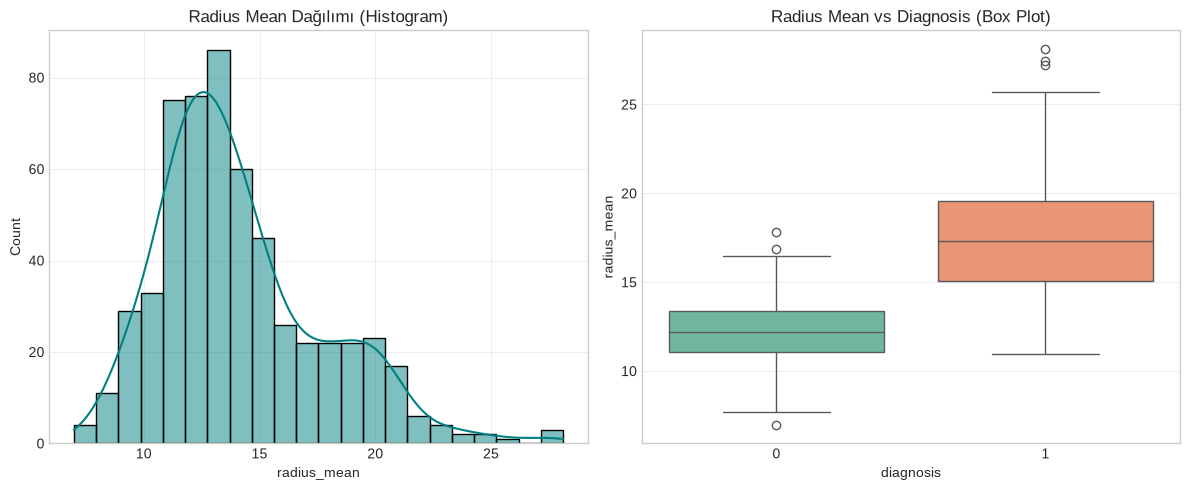

In [52]:
# --- 6. Visualization ---
print("\n6. Görselleştirme: Dağılım ve Aykırı Değer (Outlier) İncelemesi")
plt.figure(figsize=(12, 5))

# Histogram ile dağılım şeklini inceleme
plt.subplot(1, 2, 1)
sns.histplot(df["radius_mean"], kde=True, color="teal")
plt.title("Radius Mean Dağılımı (Histogram)")

# Box plot ile aykırı değerleri inceleme
plt.subplot(1, 2, 2)
sns.boxplot(x=df["diagnosis"], y=df["radius_mean"], palette="Set2")
plt.title("Radius Mean vs Diagnosis (Box Plot)")

plt.tight_layout()
plt.show()

In [53]:
# --- 7. Train Test Split ---
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n7. Veri Bölündü -> Train: {X_train.shape}, Test: {X_test.shape}")


7. Veri Bölündü -> Train: (455, 30), Test: (114, 30)


In [54]:
# --- 8. Feature Extraction ---
def extract_features(data):
    df_feat = data.copy()
    if "area_mean" in df_feat.columns and "perimeter_mean" in df_feat.columns:
        df_feat["area_perim_ratio_mean"] = df_feat["area_mean"] / (
            df_feat["perimeter_mean"] + 1e-5
        )
    if "area_worst" in df_feat.columns and "perimeter_worst" in df_feat.columns:
        df_feat["area_perim_ratio_worst"] = df_feat["area_worst"] / (
            df_feat["perimeter_worst"] + 1e-5
        )
    if "radius_worst" in df_feat.columns and "radius_mean" in df_feat.columns:
        df_feat["radius_diff"] = df_feat["radius_worst"] - df_feat["radius_mean"]
    if "texture_worst" in df_feat.columns and "texture_mean" in df_feat.columns:
        df_feat["texture_diff"] = (
            df_feat["texture_worst"] - df_feat["texture_mean"]
        )
    return df_feat

X_train_extracted = extract_features(X_train)
X_test_extracted = extract_features(X_test)
print(f"8. Feature Extraction Sonrası Train Boyutu: {X_train_extracted.shape}")

8. Feature Extraction Sonrası Train Boyutu: (455, 34)


In [55]:
# --- 9. Correlation Filter (Sadece Eğitim Seti Üzerinde) ---
corr_matrix = X_train_extracted.select_dtypes(
    include=[np.number]
).corr().abs()
corr_threshold = 0.85
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop_corr = [
    col for col in upper_tri.columns if any(upper_tri[col] > corr_threshold)
]

X_train_reduced = X_train_extracted.drop(columns=to_drop_corr)
X_test_reduced = X_test_extracted.drop(columns=to_drop_corr, errors="ignore")
print(f"9. Korelasyon Filtresi Sonrası Kalan Özellik Sayısı: {X_train_reduced.shape[1]}")

9. Korelasyon Filtresi Sonrası Kalan Özellik Sayısı: 18


In [56]:
# --- 10. Veriyi Ölçeklendirme ---
scaler = StandardScaler()
scaler.set_output(transform="pandas")
X_train_reduced = scaler.fit_transform(X_train_reduced)
X_test_reduced = scaler.transform(X_test_reduced)


11. Feature Selection Tamamlandı. Seçilen En İyi 10 Özellik:
   1. radius_mean
   2. texture_mean
   3. smoothness_mean
   4. compactness_mean
   5. symmetry_mean
   6. radius_se
   7. concave points_se
   8. smoothness_worst
   9. symmetry_worst
   10. texture_diff

Nihai Özellikler Arası Korelasyon Analizi (analysis_utils):
=== Target ile Korelasyon Sıralaması ===
radius_mean          0.728160
compactness_mean     0.606479
radius_se            0.558572
smoothness_worst     0.431637
symmetry_worst       0.426215
texture_mean         0.413595
concave points_se    0.402364
smoothness_mean      0.388584
texture_diff         0.380243
symmetry_mean        0.341308
Name: diagnosis, dtype: float64
----------------------------------------


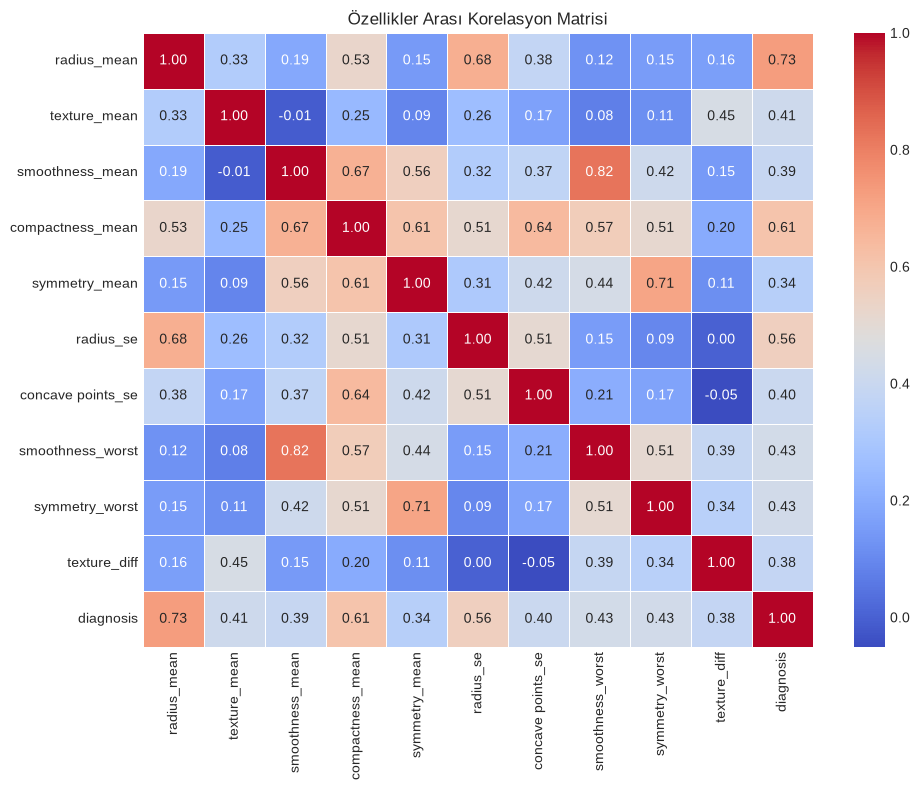

⚠️ Yüksek korelasyonlu (çakışan) özellikler: []


In [57]:
# --- 11. Feature Selection (SelectKBest / ANOVA) ---
k_best_count = 10
selector = SelectKBest(score_func=f_classif, k=k_best_count)

X_train_selected_array = selector.fit_transform(X_train_reduced, y_train)
selected_mask = selector.get_support()
final_features = X_train_reduced.columns[selected_mask]

# Nihai Havuzlar
X_train_final = X_train_reduced[final_features]
X_test_final = X_test_reduced[final_features]

print(f"\n11. Feature Selection Tamamlandı. Seçilen En İyi {k_best_count} Özellik:")
for i, feat in enumerate(final_features, 1):
    print(f"   {i}. {feat}")

# Index uyumsuzluğunu gidermek için hepsini sıfırlıyoruz
X_train_final = X_train_final.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test_final = X_test_final.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Artık güvenle birleştirebilirsin
df_train_final = pd.concat([X_train_final, y_train], axis=1)

# Nihai veri çerçevesi üzerinden analysis_utils fonksiyonu ile temiz korelasyon görselleştirmesi
df_train_final = pd.concat([X_train_final, y_train], axis=1)
print("\nNihai Özellikler Arası Korelasyon Analizi (analysis_utils):")
target_corr, to_drop = analyze_feature_correlations(
    df_train_final, target_col="diagnosis", corr_threshold=0.85
)